# 03 · feature engineering

technical features off the price panel, then join them to the labels -> one modeling-ready table.
run 01 and 02 first. everything is computed on the whole price matrix at once (vectorized), so ~2k
funds is fast. all features are scale-free so a 20 etf and a 500 etf are comparable.

In [1]:
import yaml, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200, 'display.max_columns', 40)

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW  = ROOT / cfg['paths']['raw']
PROC = ROOT / cfg['paths']['processed']; PROC.mkdir(parents=True, exist_ok=True)
prices   = pd.read_parquet(RAW / 'prices.parquet')
metadata = pd.read_parquet(RAW / 'metadata.parquet')
prices.index.name = 'date'; prices.columns.name = 'ticker'

# drop leveraged/inverse etfs and broken price series (same as nb02)
bad = pd.Series(False, index=metadata.index)
if cfg.get('exclude_leveraged') and 'is_leveraged' in metadata.columns:
    bad |= metadata['is_leveraged'].fillna(False)
if 'bad_ticks' in metadata.columns:
    bad |= metadata['bad_ticks'].fillna(False)
if cfg.get('exclude_delisted') and 'is_delisted' in metadata.columns:
    bad |= metadata['is_delisted'].fillna(False)
prices = prices.drop(columns=[c for c in metadata.index[bad] if c in prices.columns])
fcfg = cfg['features']
print('dropped', int(bad.sum()), 'funds | price panel:', prices.shape)

dropped 558 funds | price panel: (2512, 1479)


## indicators

each takes the wide price matrix (date x ticker) and returns the same shape. `fill_method=None`
on pct_change so we dont fabricate returns across the pre-launch NaN gap.

In [2]:
def realized_vol(px, w, ann=True):
    v = np.log(px).diff().rolling(w).std()
    return v * np.sqrt(252) if ann else v

def rsi(px, p=14):
    d = px.diff(); up = d.clip(lower=0); dn = -d.clip(upper=0)
    ag = up.ewm(alpha=1/p, adjust=False, min_periods=p).mean()
    al = dn.ewm(alpha=1/p, adjust=False, min_periods=p).mean()
    return 100 - 100 / (1 + ag / al)

def macd(px, fast, slow, signal):
    line = px.ewm(span=fast, adjust=False).mean() - px.ewm(span=slow, adjust=False).mean()
    sig = line.ewm(span=signal, adjust=False).mean()
    return line, sig, line - sig     # price-unit; we normalize by price below

def bollinger(px, w, k):
    mid = px.rolling(w).mean(); sd = px.rolling(w).std()
    pctb = (px - (mid - k*sd)) / (2*k*sd)
    return pctb, (2*k*sd) / mid      # %b and bandwidth (both scale-free)

## build the feature panel

returns, vol, distance-from-moving-average, rsi, macd (÷price so its comparable), bollinger.

In [3]:
feat = {}
feat['ret_1d'] = prices.pct_change(fill_method=None)
for w in fcfg['return_windows']:
    feat[f'ret_{w}d'] = prices.pct_change(w, fill_method=None)
feat[f"vol_{fcfg['vol_window']}d"] = realized_vol(prices, fcfg['vol_window'], fcfg.get('vol_annualize', True))
for w in fcfg['sma_windows']:
    feat[f'px_to_sma_{w}'] = prices / prices.rolling(w).mean() - 1.0
for w in fcfg['ema_windows']:
    feat[f'px_to_ema_{w}'] = prices / prices.ewm(span=w, adjust=False).mean() - 1.0
feat[f"rsi_{fcfg['rsi_period']}"] = rsi(prices, fcfg['rsi_period'])
m = fcfg['macd']; line, sig, hist = macd(prices, m['fast'], m['slow'], m['signal'])
feat['macd'] = line / prices; feat['macd_signal'] = sig / prices; feat['macd_hist'] = hist / prices
b = fcfg['bollinger']; pctb, bw = bollinger(prices, b['window'], b['num_std'])
feat['bb_pctb'] = pctb; feat['bb_bandwidth'] = bw

# stack each wide frame to long (date, ticker) and glue together
features = pd.concat({k: v.stack(future_stack=True) for k, v in feat.items()}, axis=1)
features.index.names = ['date', 'ticker']
features = features.dropna(how='all')          # drop pre-launch rows (all features NaN)
print('features:', features.shape)
features.tail(3).T

features: (3359826, 17)


date         2026-07-08                      
ticker              YYY        ZIG       ZROZ
ret_1d        -0.004333  -0.008965  -0.002122
ret_5d        -0.003469  -0.016415  -0.034287
ret_10d        0.014934  -0.009271  -0.035490
ret_20d        0.032993  -0.014273  -0.002221
vol_20d        0.058919   0.129049   0.171872
px_to_sma_10   0.001210  -0.014586  -0.032076
px_to_sma_20   0.010657  -0.018454  -0.029568
px_to_sma_50   0.015044  -0.019173  -0.013110
px_to_ema_10   0.001537  -0.011779  -0.022198
px_to_ema_20   0.006875  -0.015640  -0.024390
px_to_ema_50   0.016623  -0.017905  -0.021184
rsi_14        61.215503  39.872728  38.477727
macd           0.006334  -0.004034   0.000181
macd_signal    0.005117  -0.002050   0.005902
macd_hist      0.001217  -0.001984  -0.005721
bb_pctb        0.721748   0.042303   0.079207
bb_bandwidth   0.048061   0.040319   0.070267

In [4]:
features.to_parquet(PROC / 'features.parquet')
print('saved', features.shape, '->', PROC / 'features.parquet')

saved (3359826, 17) -> C:\Users\user\Desktop\CS\overp\outperforming\data\processed\features.parquet


## modeling-ready dataset

join features onto the labels from notebook 02. inner join keeps only (date, fund) rows that
have both a label and prices; then drop warm-up rows where the long-lookback features are still NaN.

In [5]:
labels = pd.read_parquet(PROC / 'labels.parquet')
dataset = features.join(labels[['label', 'rel', 'category']], how='inner').dropna()
dataset.to_parquet(PROC / 'dataset.parquet')
print('dataset:', dataset.shape)
print(dataset['label'].value_counts())
dataset.head()

dataset: (2999050, 20)
label
Neutral         1566810
Outperform       716910
Underperform     715330
Name: count, dtype: int64


ret_1d    ret_5d   ret_10d   ret_20d   vol_20d  px_to_sma_10  px_to_sma_20  px_to_sma_50  px_to_ema_10  px_to_ema_20  px_to_ema_50     rsi_14      macd  macd_signal  macd_hist  \
date       ticker                                                                                                                                                                                      
2016-09-19 AADR    0.000000 -0.015358 -0.037411 -0.042595  0.159274     -0.017534     -0.027780     -0.032482     -0.013243     -0.022389     -0.026287  40.348344 -0.009490    -0.005080  -0.004411   
           AAXJ    0.007937  0.001847 -0.002173  0.003699  0.182940     -0.001071      0.004891      0.021044      0.004099      0.005855      0.019925  55.761109  0.004133     0.006193  -0.002061   
           ACWF   -0.019562 -0.019562 -0.002826 -0.002997  0.096161     -0.017640     -0.010382      0.005313     -0.013729     -0.010042      0.005302  41.454211  0.006347     0.007953  -0.001606   
           ACWI    0.002594 -0.012770 -0.020939 -0.020112  0.133928     -0.008736     -0.012207     -0.007803     -0.005274     -0.008886     -0.006206  46.317589 -0.002771     0.000083  -0.002854   
           ACWX    0.006439 -0.016219 -0.024718 -0.017646  0.148885     -0.011625     -0.012598     -0.002949     -0.006121     -0.009050     -0.002400  47.922646 -0.001261     0.002432  -0.003693   

                    bb_pctb  bb_bandwidth       label       rel          category  
date       ticker                                                                  
2016-09-19 AADR    0.116551      0.072447  Outperform  0.017323  Emerging Markets  
           AAXJ    0.590357      0.054127     Neutral -0.004112  Emerging Markets  
           ACWF    0.204665      0.035154     Neutral  0.001035             Blend  
           ACWI    0.208792      0.041917  Outperform  0.005132             Blend  
           ACWX    0.241148      0.048667  Outperform  0.006250             Blend

## feature distributions

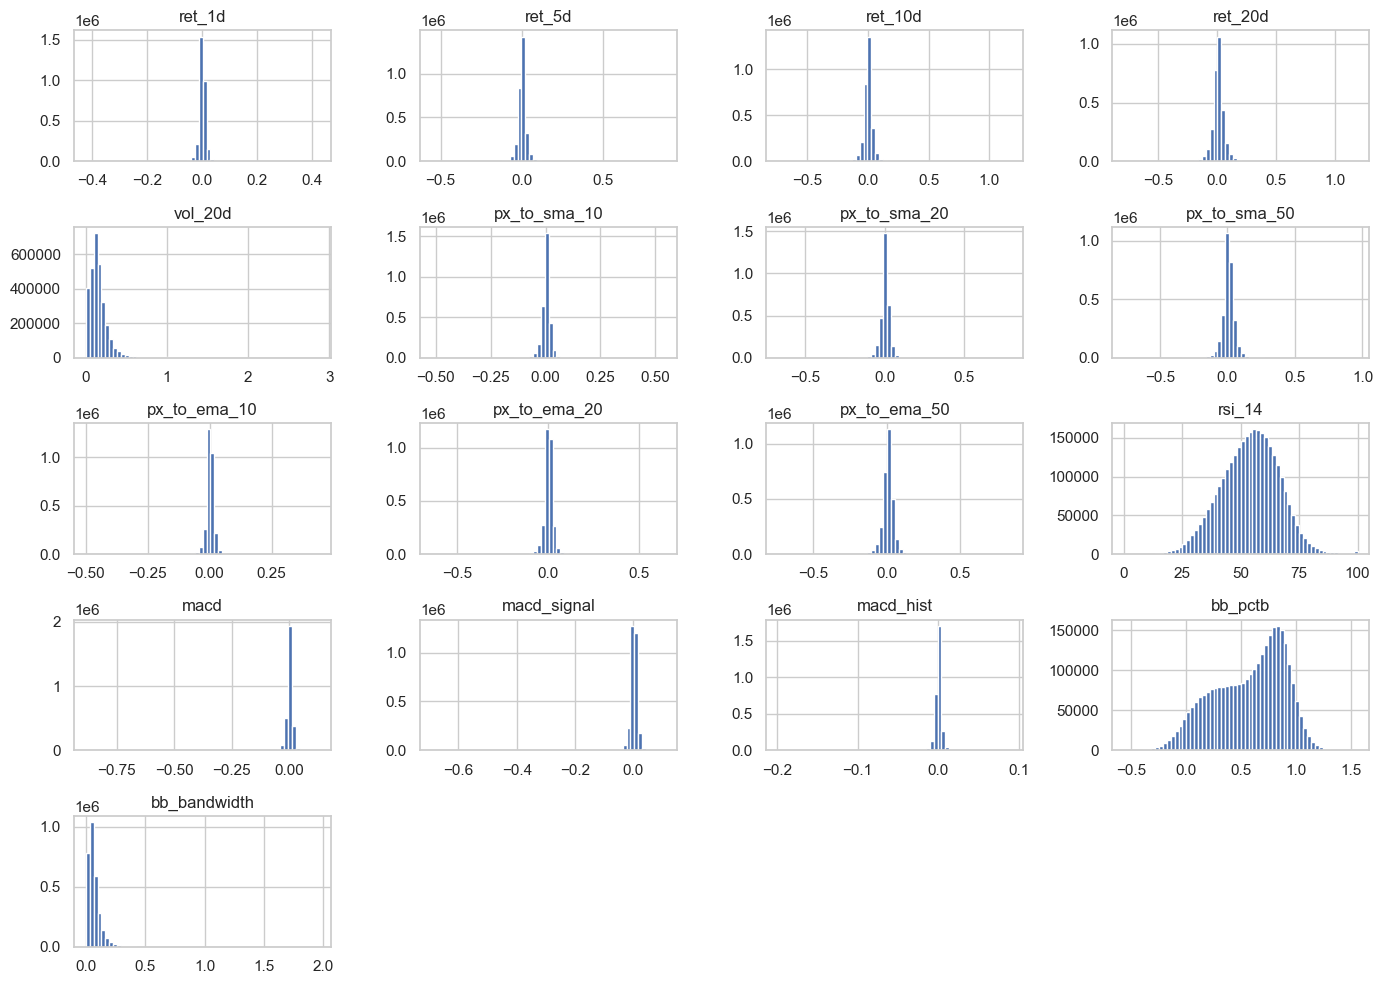

In [6]:
feat_cols = [c for c in dataset.columns if c not in ('label', 'rel', 'category')]
dataset[feat_cols].hist(bins=60, figsize=(14, 10)); plt.tight_layout(); plt.show()

## feature correlation

the moving-average distances and macd will be correlated (all momentum-ish) - expected.

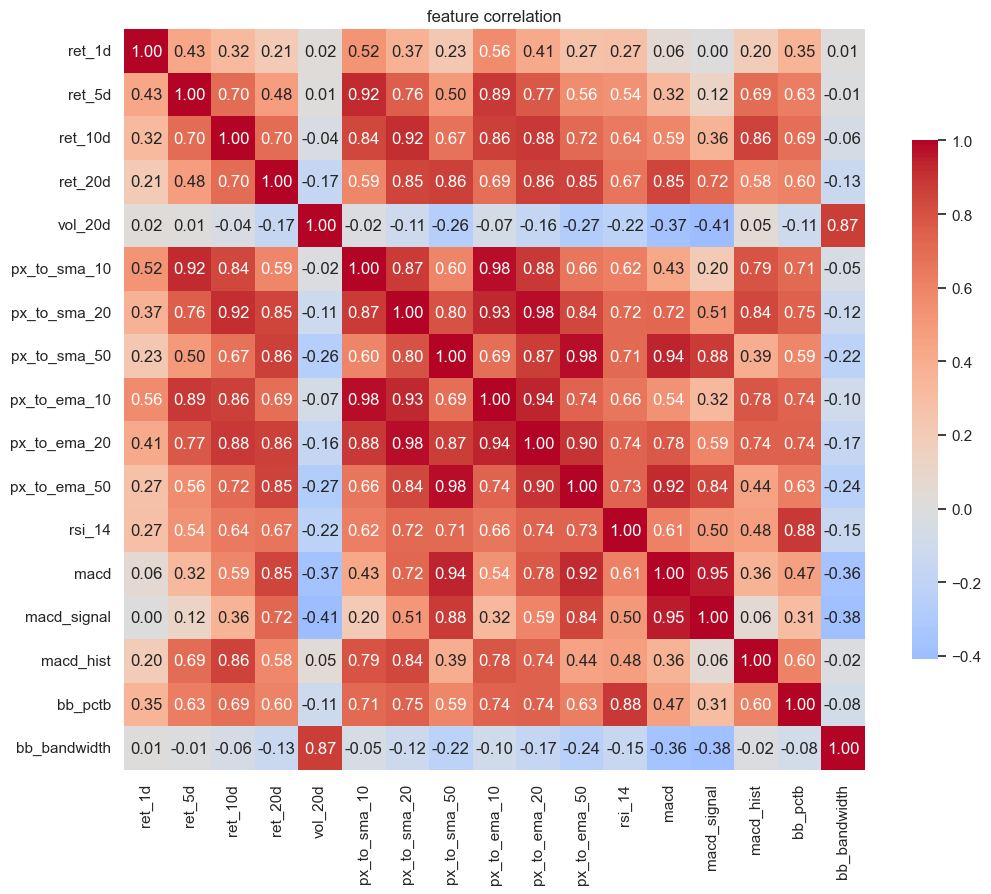

In [7]:
plt.figure(figsize=(11, 9))
sns.heatmap(dataset[feat_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': .7})
plt.title('feature correlation'); plt.tight_layout(); plt.show()

### redundant features

the sma/ema distances (and macd vs its signal) all measure momentum, so they move together.
matters for the linear baseline (multicollinearity); a tree model wont care.

In [8]:
cor = dataset[feat_cols].corr().abs()
pairs = [(feat_cols[i], feat_cols[j], cor.iloc[i, j])
         for i in range(len(feat_cols)) for j in range(i+1, len(feat_cols)) if cor.iloc[i, j] > 0.9]
print('feature pairs with |corr| > 0.9:')
for a, b, v in sorted(pairs, key=lambda x: -x[2]):
    print(f'  {a:14} ~ {b:14} {v:.2f}')

feature pairs with |corr| > 0.9:
  px_to_sma_20   ~ px_to_ema_20   0.98
  px_to_sma_50   ~ px_to_ema_50   0.98
  px_to_sma_10   ~ px_to_ema_10   0.98
  macd           ~ macd_signal    0.95
  px_to_ema_10   ~ px_to_ema_20   0.94
  px_to_sma_50   ~ macd           0.94
  px_to_sma_20   ~ px_to_ema_10   0.93
  ret_5d         ~ px_to_sma_10   0.92
  px_to_ema_50   ~ macd           0.92
  ret_10d        ~ px_to_sma_20   0.92
  px_to_ema_20   ~ px_to_ema_50   0.90


## do the features separate the classes?

mean feature value per label + boxplots. flat across labels = weak marginal signal (normal for a
5-day problem - the model leans on combinations). this is a gut check, not a verdict.

,ret_5d,ret_10d,vol_20d,rsi_14,macd_hist,bb_pctb
label,,,,,,
Neutral,0.0023,0.0044,0.1227,55.0061,0.0001,0.5885
Outperform,0.0012,0.0032,0.1942,52.9678,-0.0001,0.5510
Underperform,0.0022,0.0037,0.1934,52.9234,-0.0000,0.5536


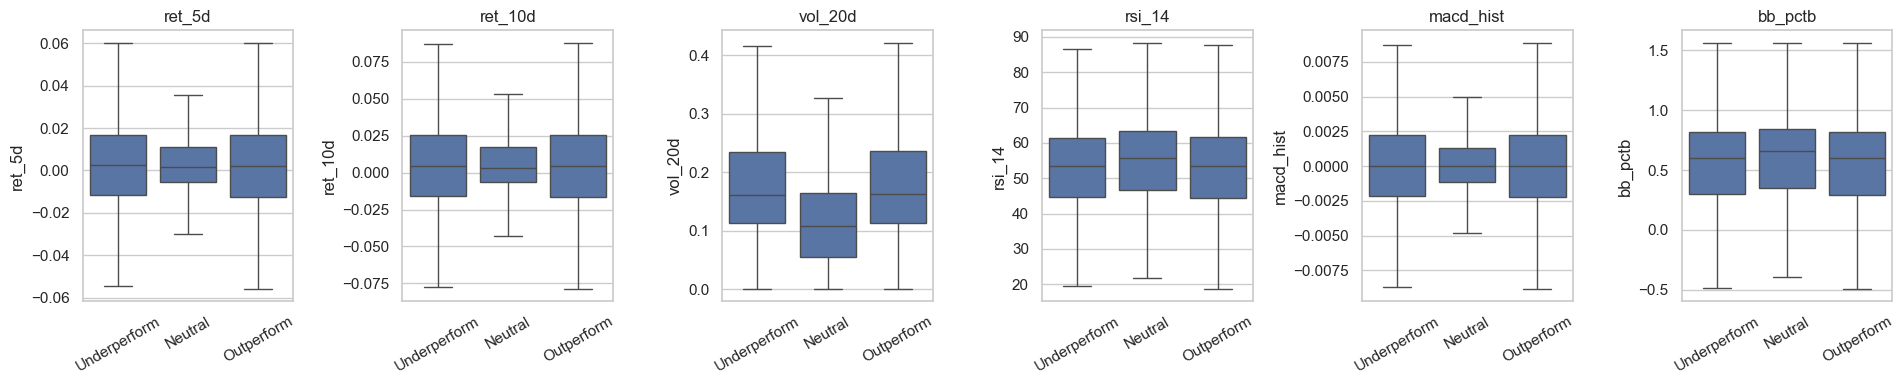

In [9]:
show = [c for c in ['ret_5d','ret_10d','vol_20d','rsi_14','macd_hist','bb_pctb'] if c in dataset.columns]
display(dataset.groupby('label')[show].mean().round(4))
fig, axes = plt.subplots(1, len(show), figsize=(3.2*len(show), 4))
for ax, cn in zip(np.atleast_1d(axes), show):
    sns.boxplot(data=dataset, x='label', y=cn, order=['Underperform','Neutral','Outperform'], ax=ax, showfliers=False)
    ax.set_title(cn); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

### how much signal is in each feature?

separation = distance between the Outperform and Underperform means, in pooled-std units. everything
is tiny (best ~0.04) -> **no single feature calls direction**. note volatility separates 'will move'
vs 'stays flat' (neutral), not which way. takeaway: this is a hard problem, expect modest accuracy,
and the model will have to lean on feature *combinations* rather than any one signal.

In [10]:
mu = dataset.groupby('label')[feat_cols].mean()
sep = ((mu.loc['Outperform'] - mu.loc['Underperform']).abs() / dataset[feat_cols].std())
sep.sort_values(ascending=False).round(3).to_frame('out_vs_under_separation')

,out_vs_under_separation
ret_1d,0.038
ret_5d,0.034
px_to_sma_10,0.034
px_to_ema_10,0.032
bb_bandwidth,0.021
px_to_ema_20,0.020
px_to_sma_20,0.016
ret_10d,0.015
macd_hist,0.011
px_to_ema_50,0.009


### signal, as pictures

left: the same separation, ranked. right: plain linear correlation of each feature with `rel`
(the continuous target). both confirm the signal is real but thin.

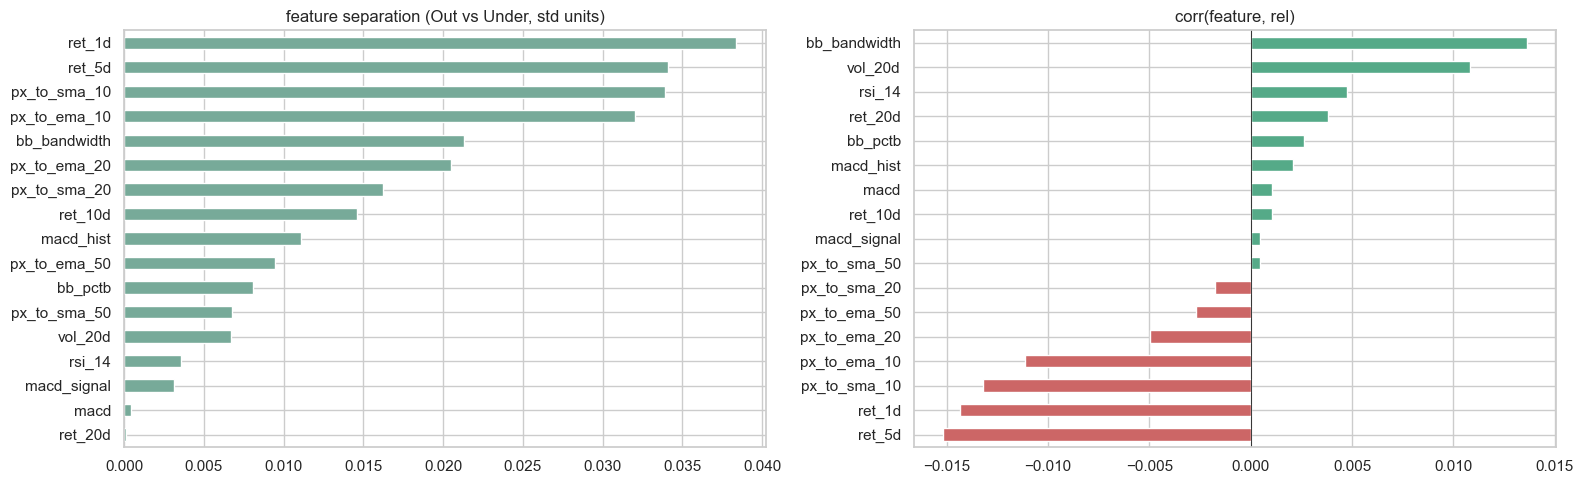

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sep.sort_values().plot.barh(ax=ax[0], color='#7a9'); ax[0].set_title('feature separation (Out vs Under, std units)')
corr_t = dataset[feat_cols].corrwith(dataset['rel']).sort_values()
corr_t.plot.barh(ax=ax[1], color=np.where(corr_t > 0, '#5a8', '#c66')); ax[1].axvline(0, color='k', lw=.6)
ax[1].set_title('corr(feature, rel)')
plt.tight_layout(); plt.show()

### does P(outperform) move with a feature?  (the useful one)

bucket each feature into deciles, plot the outperform-rate per bucket (dotted line = base rate ~24%).
this reveals **nonlinear signal the linear separation metric completely missed**:
- **momentum (ret_5d, px_to_sma_10, macd_hist) makes a clear V** - both the week's biggest losers
  *and* biggest winners are more likely to beat peers next week (~33% vs ~15% in the middle).
- **vol_20d rises monotonically** - more volatile funds deviate up more often (top decile ~37%).
- **rsi_14 and bb_pctb fall** - overbought funds mean-revert down.

takeaway: there IS exploitable signal, but it's nonlinear and V-shaped - so **use tree/boosting
models, not just logistic regression** (a linear model can't fit a V).

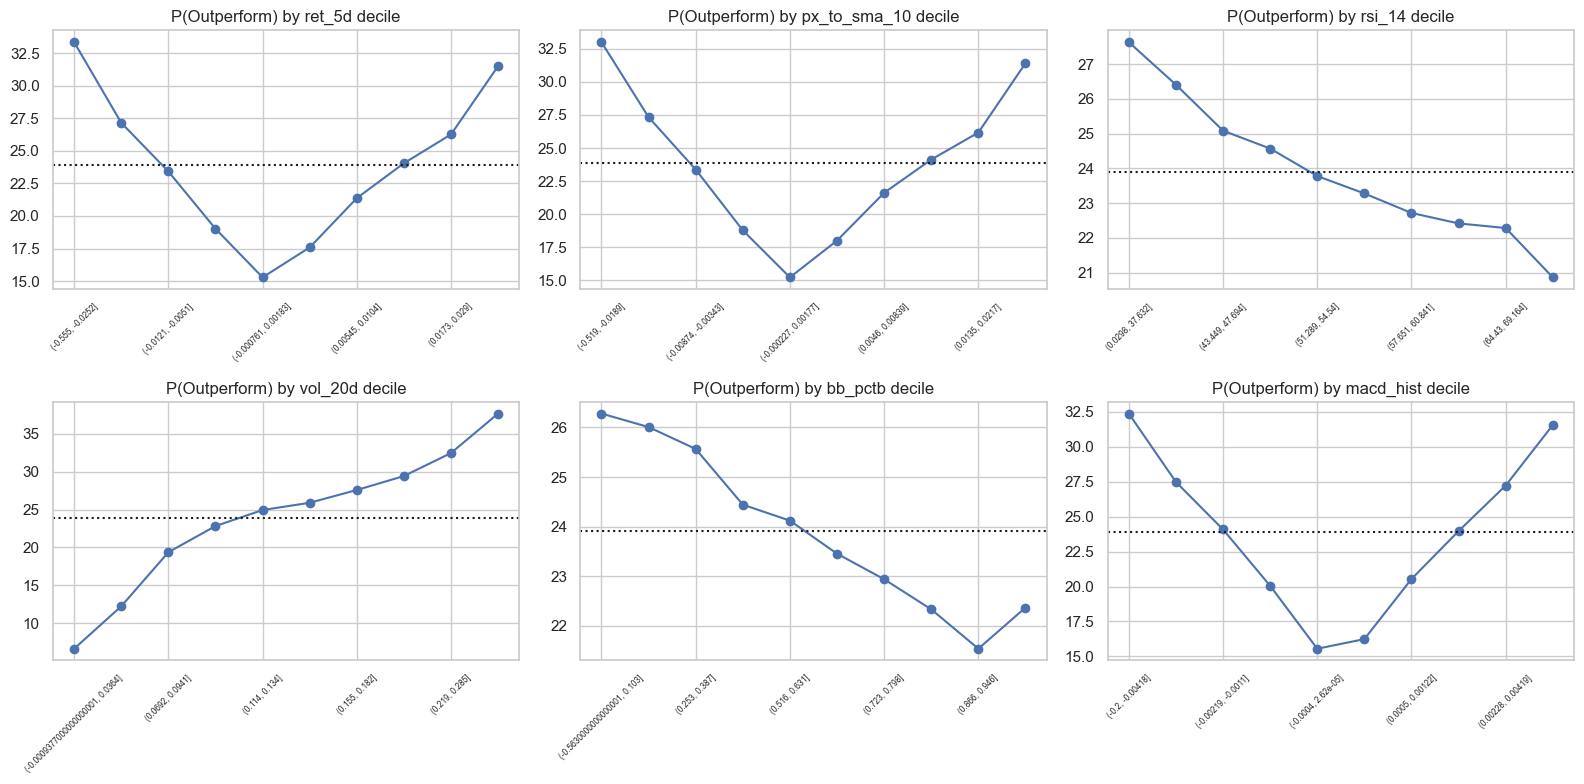

In [12]:
show = [c for c in ['ret_5d','px_to_sma_10','rsi_14','vol_20d','bb_pctb','macd_hist'] if c in dataset.columns]
base = (dataset['label'] == 'Outperform').mean() * 100
is_out = (dataset['label'] == 'Outperform').astype(float)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, cn in zip(axes.ravel(), show):
    q = pd.qcut(dataset[cn], 10, duplicates='drop')
    is_out.groupby(q, observed=True).mean().mul(100).plot(ax=ax, marker='o')
    ax.axhline(base, color='k', ls=':'); ax.set_title(f'P(Outperform) by {cn} decile')
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=45, labelsize=6)
plt.tight_layout(); plt.show()